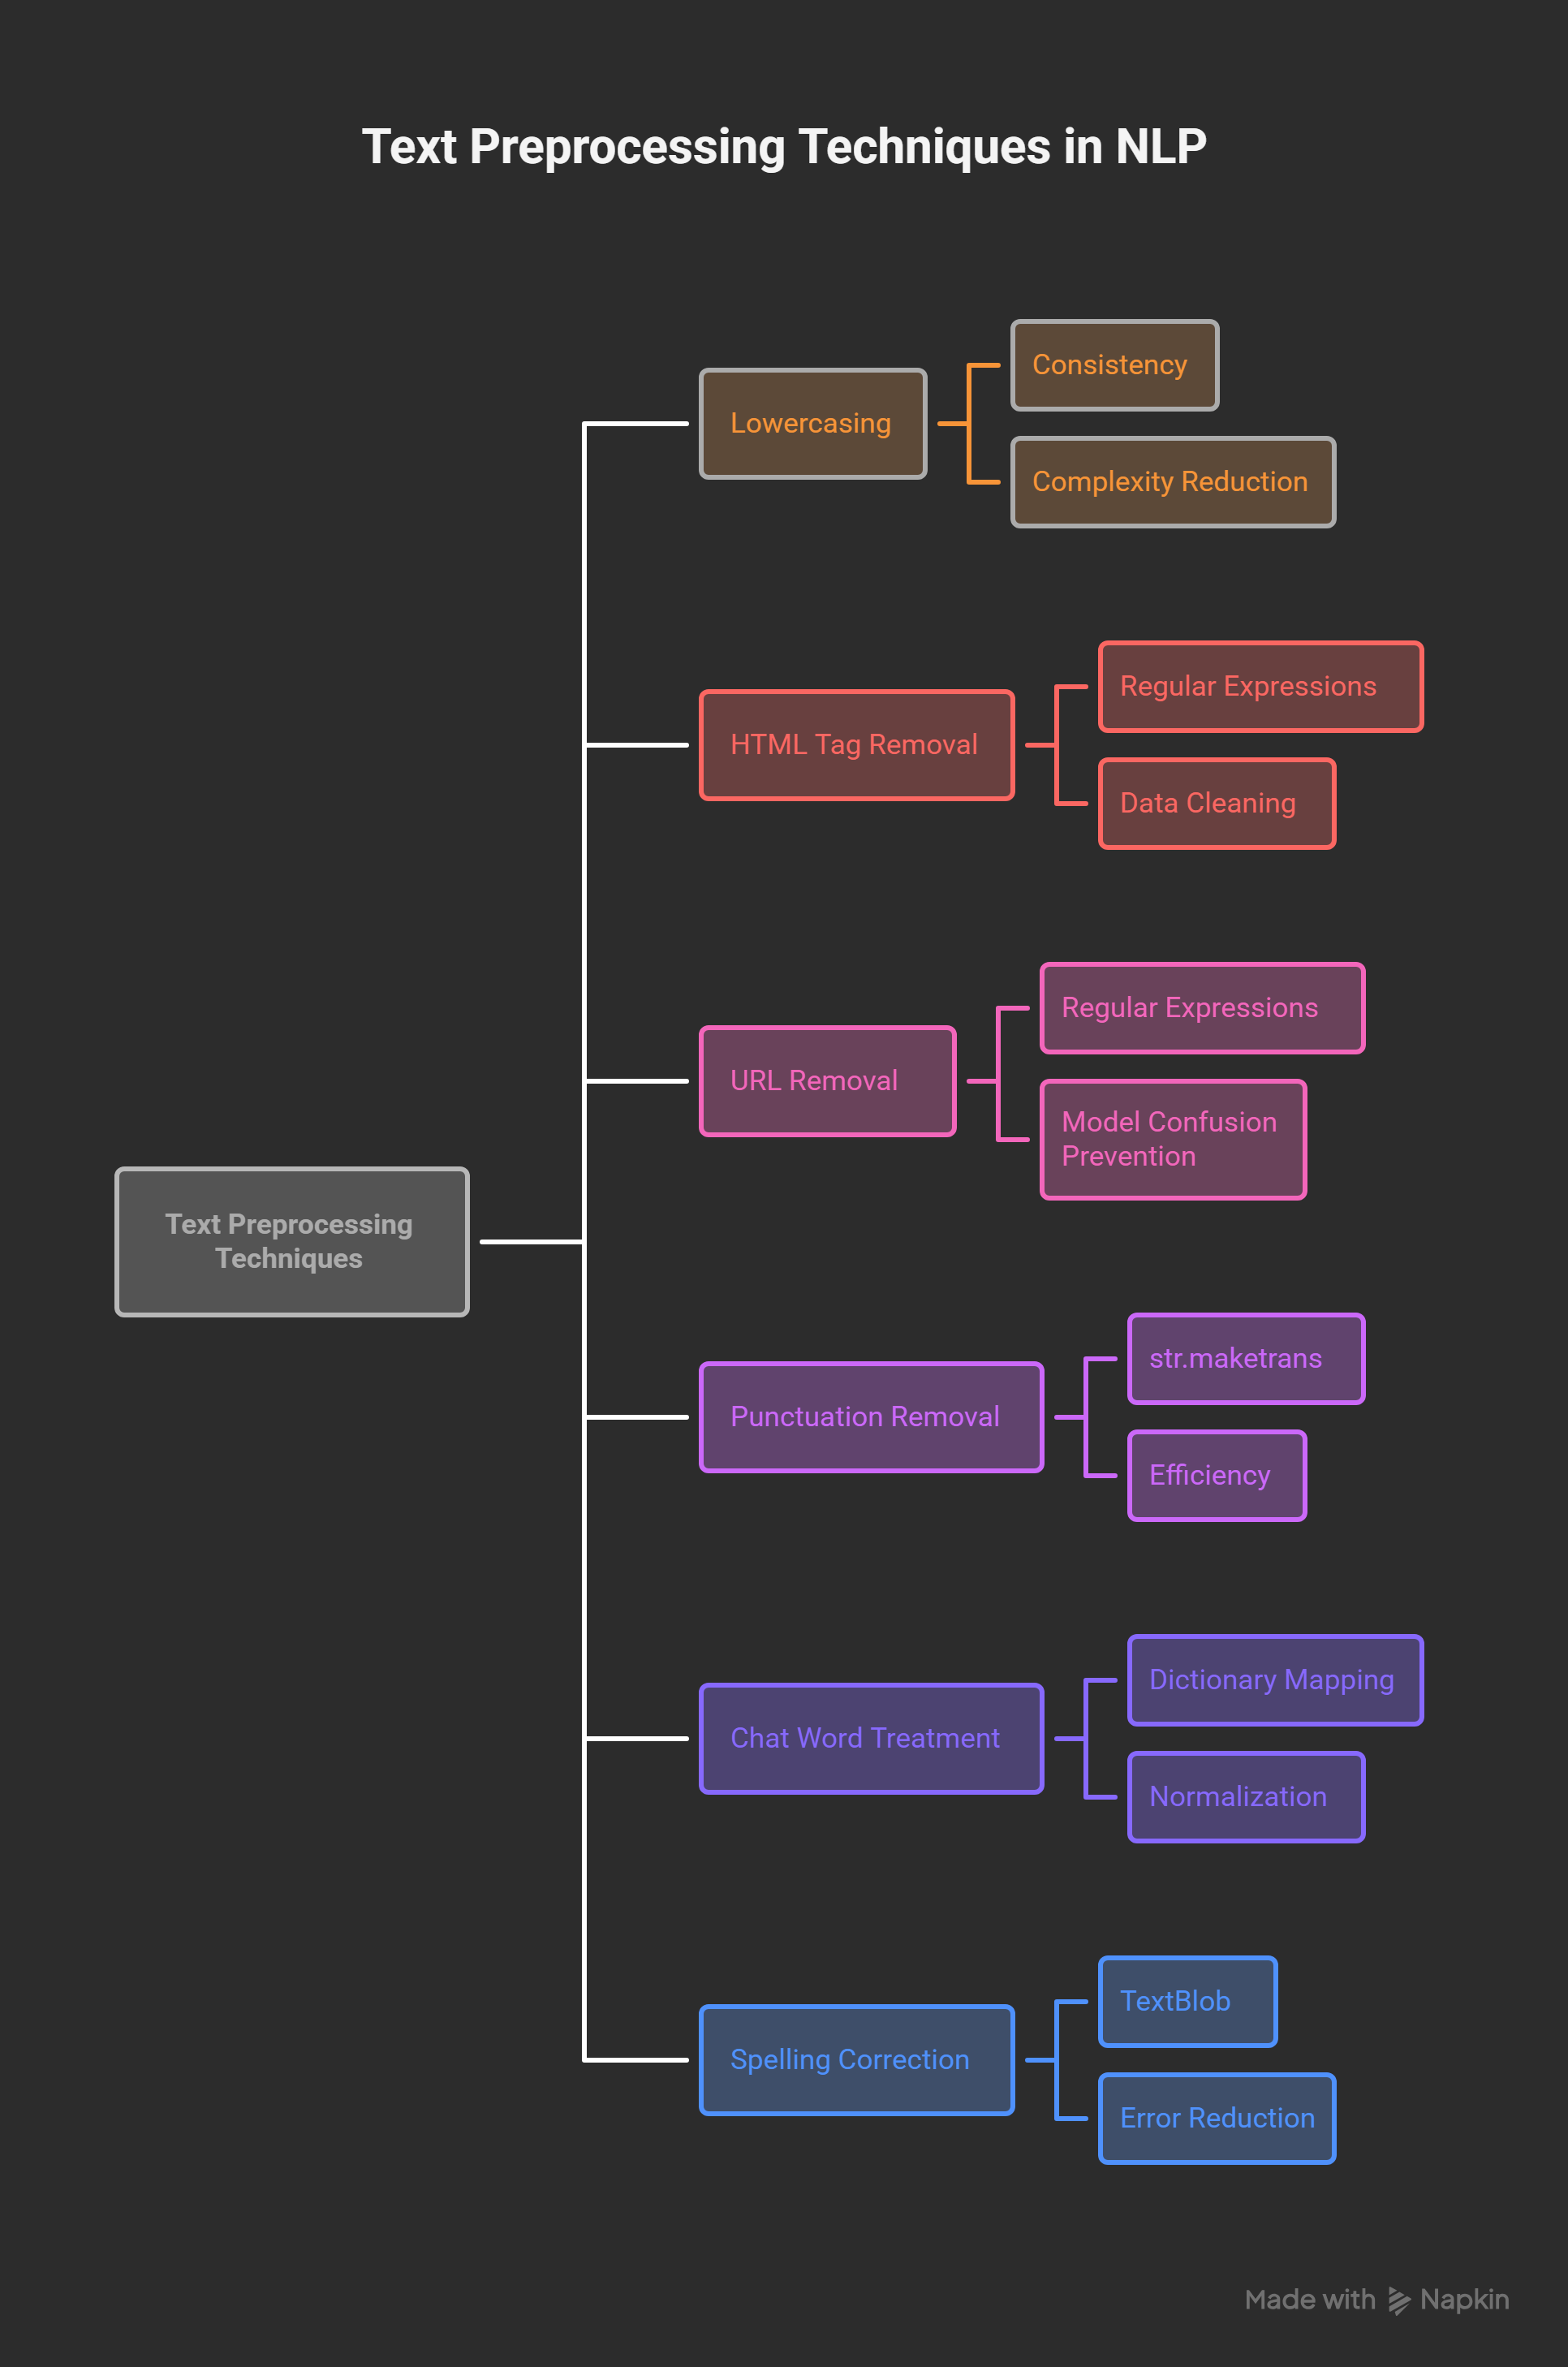

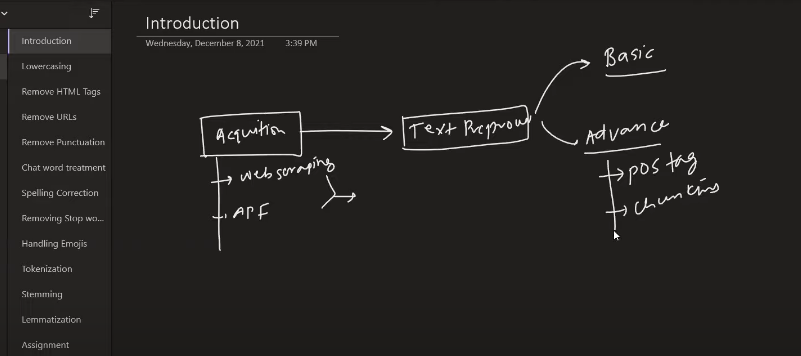



### Basic Text Preprocessing Steps

1.  **Lowercasing**
    The process should generally begin by converting all text to lowercase. Lowercasing ensures that words that are grammatically capitalized (like the first word in a sentence) or capitalized for emphasis are not treated as distinct tokens from their lowercase counterparts. This prevents unnecessary complexity within the model.

2.  **Removal of HTML Tags**
    When data is scraped from websites (e.g., IMDb), it often contains HTML tags. Since these tags are only relevant for instructing a browser on data display and do not contribute to NLP tasks like sentiment analysis, they must be removed. This is typically achieved using regular expressions (regex).

3.  **Removal of URLs**
    URLs frequently appear in social media or messaging data (e.g., Twitter, WhatsApp). They usually do not contribute significant meaning to the analysis (like classification or sentiment analysis) and can confuse the model. Regular expressions are employed to detect and remove these URLs.

4.  **Removal of Punctuations**
    Punctuation marks (such as commas, question marks, and exclamation marks) are generally removed in approximately 99% of NLP tasks. Retaining them can create complications: either they are treated as unique, useless words (tokens), unnecessarily enlarging the document, or they are attached to words, causing the model to treat the same word with and without punctuation as two separate entries. A fast, standardized technique using `str.maketrans` is recommended for efficient removal across large datasets.

5.  **Chat Word Treatment (Expansion)**
    In data sourced from messaging apps or social media, users often employ short forms or slang (e.g., 'IMHO', 'ASAP', 'GN'). For effective processing, these short forms should be normalized and replaced with their complete, standard phrases (e.g., 'Good Night'). This requires utilizing a dictionary that maps short forms to their expansions.

6.  **Spelling Correction**
    If the text data is prone to spelling errors, correction is necessary. Mistakes lead to unnecessary complexity by creating distinct words (tokens) that should otherwise be identical. Libraries such as TextBlob can be used to handle common spelling errors.

7.  **Stop Word Removal**
    Stop words are common words (like 'the', 'a', 'is', 'of') that aid in sentence formation but do not contribute to the overall meaning or sentiment of the sentence. For tasks like sentiment analysis or document classification, stop words are removed, typically using pre-built lists found in libraries like NLTK. However, some tasks, such as Parts-of-Speech tagging, require stop words to remain.

8.  **Handling Emojis**
    The frequent use of emojis in modern communication means they must be addressed. Two main approaches exist:
    *   **Removal:** Using regular expressions (specifically tailored for different Unicode patterns like transport, symbols, or flags) to completely delete the emoji from the text.
    *   **Replacement:** Utilizing a module like `emoji` to replace the visual emoji with its descriptive text meaning (e.g., replacing 😃 with 'grinning face').

9.  **Tokenization**
    Tokenization is the foundational process of segmenting a text document into smaller components called tokens, which can be words, sentences, or phrases. Word tokenization is the most common approach.
    *   **Importance:** Proper tokenization is vital because it directly impacts subsequent feature engineering (like counting unique words); incorrect tokenization confuses the model.
    *   **Challenges:** Simple splitting functions often fail when dealing with complex scenarios involving punctuation attached to words, contractions, or unique structures like currency ($20) or measurements (10km).
    *   **Techniques:** While simple Python `.split()` or tailored regular expressions can be used, the **best results** are generally achieved by using sophisticated libraries like **SpaCy**, which handles challenging structures better than NLTK or basic splitting functions.

10. **Stemming and Lemmatization**
    These techniques aim to reduce inflected words (words modified to express grammatical categories like tense or number, e.g., 'walk', 'walking', 'walked') back to a root form.

    *   **Stemming:** This process reduces an inflected word to a "stem" or root form, which is useful for Information Retrieval Systems (like search engines). Stemmers (like the Porter Stemmer in NLTK) use algorithms to clip prefixes and suffixes. A major characteristic of stemming is that the resulting stem may not be a valid word in the English language (e.g., 'probabli' instead of 'probably'). Stemming is typically faster.
    *   **Lemmatization:** Similar to stemming, it reduces a word to its root form, known as the "lemma," but the lemma is always guaranteed to be a valid word found in the language dictionary. Lemmatization is often performed by searching a lexical dictionary, such as WordNet (accessible via NLTK). Because it relies on dictionary lookups, it is slower than stemming. Lemmatization is preferred when the output needs to be comprehensible to a user, and it often requires specifying the Part-of-Speech (POS) of the word for accurate results.



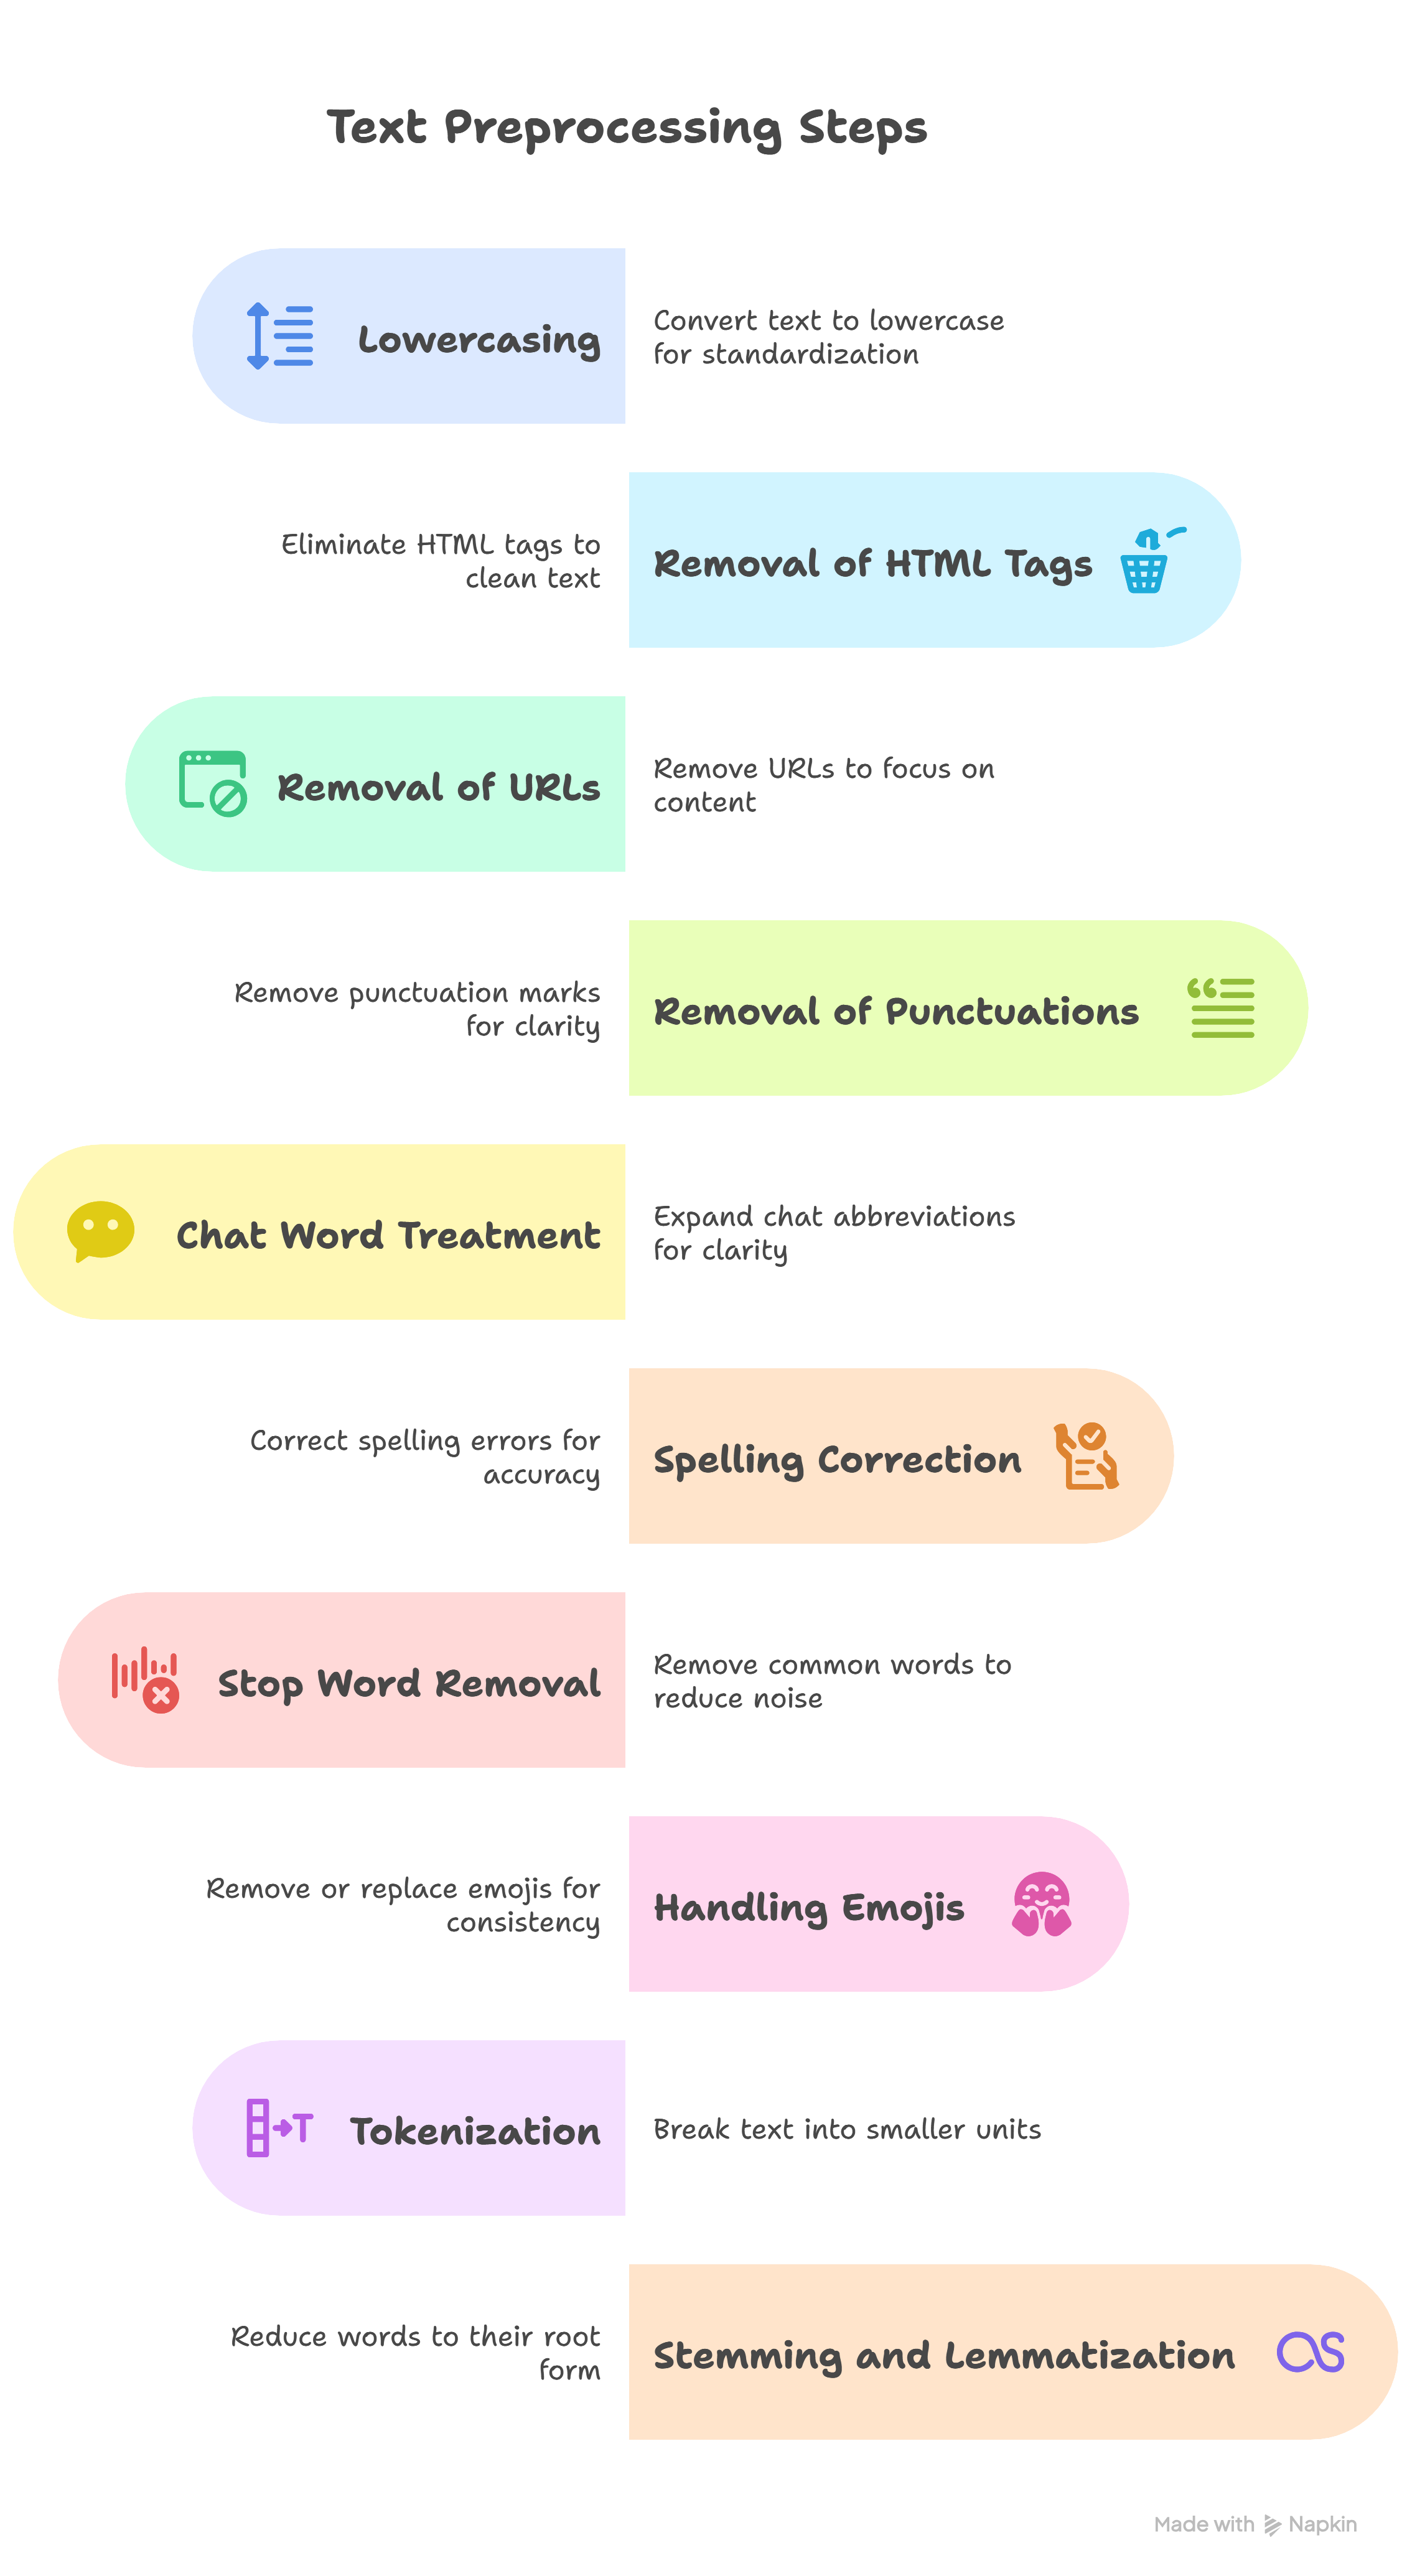



---

## Basic Text Preprocessing Steps

### 1. Lowercasing

This step standardizes text by converting all characters to lowercase to prevent unnecessary model complexity.

| Operation | Code Snippet | Source |
| :--- | :--- | :--- |
| **Simple String Lowercasing** | `text.lower()` | |
| **DataFrame Column Lowercasing** | `df['reviews'].str.lower().values` | |

### 2. Removal of HTML Tags

HTML tags (common when data is web-scraped) are removed as they do not contribute to tasks like sentiment analysis and can confuse the model. This is typically achieved using the Regular Expression (re) module in Python.

```python
import re

def remove_html_tags(text):
    # This regex pattern finds any text enclosed by angle brackets
    pattern = re.compile('<[^>]*>')
    return pattern.sub('', text)

# Application to a single string:
# cleaned_text = remove_html_tags(text_with_tags)

# Application to a DataFrame column (Example):
# df['reviews'] = df['reviews'].apply(remove_html_tags)
```
*(Note: The function name `remove_html_tags` is used based on the function definition in the source material. The exact application syntax for the DataFrame `df['reviews'].apply(remove_html_tags)` is also supported.)*

### 3. Removal of URLs

URLs found frequently in social media or messaging data are removed using regular expressions, as they seldom contribute meaningful information to the analysis.

```python
import re

# This function uses a comprehensive regex pattern to match URLs
# starting with http/https, www, or other common formats.

def remove_urls(text):
    # Note: The exact regex pattern provided in the source is complex,
    # but the principle involves using re.sub() with an appropriate pattern.
    url_pattern = re.compile(r'https?://\S+|www\.\S+|\S+\.\S+')
    return url_pattern.sub(r'', text)

# Example application:
# text_without_urls = remove_urls(text_containing_urls)
```

### 4. Removal of Punctuations

Punctuation marks are generally removed in approximately 99% of NLP tasks to prevent them from becoming separate, useless tokens or complicating tokenization by attaching to words.

**Preferred Technique: Fast, Standardized Method using `str.maketrans`**

This method is highly recommended, especially when working with large datasets, as it is significantly faster (demonstrated to be 15 times faster than custom loop logic).

```python
import string

# Define the set of punctuation marks to be excluded
EXCLUDED = string.punctuation

def remove_punct_one(text):
    # str.maketrans creates a translation table
    # text.translate performs the replacement efficiently
    return text.translate(str.maketrans('', '', EXCLUDED))

# Example application to a DataFrame column:
# df['tweet'] = df['tweet'].apply(remove_punct_one)
```

### 5. Chat Word Treatment (Expansion)

If the data originates from messaging or social platforms, short forms (e.g., 'IMHO', 'ASAP') must be converted to their full, normal form using a dictionary lookup.

```python
# Assuming 'chat_words_dict' is the pre-loaded dictionary
# mapping short forms (keys) to their expansions (values).

def chat_conversion(text, chat_words_dict):
    new_text = []
    # Split the input text into individual words
    for word in text.split():
        # Check if the word is a known chat short form (key in the dictionary)
        if word.upper() in chat_words_dict:
            # Append the expanded phrase
            new_text.append(chat_words_dict[word.upper()])
        else:
            # Append the original word
            new_text.append(word)
    # Rejoin the words with spaces
    return " ".join(new_text)

# Example application:
# expanded_text = chat_conversion("IMHO, he is the best", chat_words_dict)
```

### 6. Spelling Correction

Spelling correction is crucial when dealing with text prone to errors, as mistakes create distinct tokens that should be identical, adding complexity. The TextBlob library is used for this purpose.

```python
from textblob import TextBlob

def correct_spelling(text):
    # Create a TextBlob object
    text_blob = TextBlob(text)
    # Use the .correct() method and convert the result back to string
    return str(text_blob.correct())

# Example application:
# corrected = correct_spelling("Pleas reed and lik the not book")
```

### 7. Stop Word Removal

Common words (stop words) that aid in sentence structure but do not contribute to core meaning or sentiment (like 'the', 'is', 'a') are removed, usually using pre-built lists from NLTK.

```python
import nltk
from nltk.corpus import stopwords

# Download stop words if not already present (assumed to be done prior)
# nltk.download('stopwords')

# Load the list of English stop words
STOP_WORDS_ENGLISH = stopwords.words('english')

def remove_stopwords(text):
    # Split the text into words
    words = text.split()
    # Filter out any word present in the STOP_WORDS_ENGLISH list
    filtered_words = [word for word in words if word not in STOP_WORDS_ENGLISH]
    # Rejoin the filtered words
    return " ".join(filtered_words)

# Example application:
# cleaned_text = remove_stopwords("This is my sample text")
```

### 8. Handling Emojis

Emojis, common in modern text, must be either removed or replaced with their textual descriptions.

#### Option 1: Removal (Using Regex)

```python
import re

def remove_emoji(text):
    # This pattern targets various Unicode ranges used for emojis (symbols, transport, flags, etc.)
    # The pattern substitute the emoji unicode with an empty string.
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Symbols & Pictographs
        # ... other Unicode ranges for Transport, Flags, etc.
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# Example application:
# text_no_emoji = remove_emoji("Python is fun 😃")
```

#### Option 2: Replacement with Meaning (Using `emoji` module)

```python
import emoji

def replace_emoji(text):
    # The demojize function converts the emoji character to its descriptive text,
    # typically enclosed in colons (e.g., 😃 -> :grinning_face:).
    return emoji.demojize(text)

# Example application:
# text_with_desc = replace_emoji("I love the movie 👍")
```

### 9. Tokenization

Tokenization is the critical process of breaking text into smaller units (tokens), primarily words or sentences, ensuring proper segmentation for feature engineering. Simple methods often fail with challenging cases (e.g., punctuation attached to words, contractions, currency).

#### Method 1: Basic Python Split (Simple Text)

```python
# Word Tokenization based on space
tokens_word = sentence_one.split()

# Sentence Tokenization based on full stop (limited functionality)
tokens_sentence = text_paragraph.split('.')
```

#### Method 2: NLTK Tokenization

NLTK provides internal algorithms designed to handle more scenarios than basic split functions.

```python
from nltk.tokenize import word_tokenize, sent_tokenize

# Word Tokenization
word_tokens = word_tokenize(text)

# Sentence Tokenization
sentence_tokens = sent_tokenize(text)
```

#### Method 3: SpaCy Tokenization (Recommended)

The SpaCy library is noted as providing the most robust tokenization, handling edge cases better than NLTK or basic methods.

```python
import spacy

# Load the small English language model
# Note: This is an initial setup step
nlp = spacy.load('en_core_web_sm')

def spacy_tokenize(text):
    # Convert text to a SpaCy Document object
    doc = nlp(text)
    # Extract tokens from the document
    return [token.text for token in doc]

# Example application:
# tokens = spacy_tokenize("I have a Ph.D. in AI.")
```

### 10. Stemming and Lemmatization

These techniques reduce inflected words (e.g., 'walking', 'walked') to their root form (base form or lemma).

#### A. Stemming (Porter Stemmer)

Stemming quickly reduces a word to a "stem" by clipping prefixes/suffixes. The result is often not a valid word in the language dictionary. It is faster and useful for Information Retrieval Systems.

```python
from nltk.stem.porter import PorterStemmer

# Initialize the Porter Stemmer object
ps = PorterStemmer()

def stem_words(text):
    # Tokenize the input text (using simple split for demonstration)
    tokens = text.split()
    # Apply stemming to each token
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

# Example application:
# stemmed_text = stem_words("running walked probably")
```

#### B. Lemmatization (WordNet Lemmatizer)

Lemmatization reduces a word to its "lemma," which is guaranteed to be a valid word in the language dictionary. It requires consulting a lexical dictionary (like WordNet) and is thus slower than stemming. It often requires specifying the Part-of-Speech (POS) tag for accuracy.

```python
from nltk.stem import WordNetLemmatizer
# NLTK's WordNet resource must be imported/downloaded for lookup
# from nltk.corpus import wordnet # Implicitly required

# Initialize the WordNet Lemmatizer object
wnl = WordNetLemmatizer()

def lemmatize_word(word, pos='n'):
    # Lemmatization relies on dictionary lookup.
    # 'pos' (Part-of-Speech) parameter is crucial for correct results
    # (e.g., 'n' for noun, 'v' for verb).
    return wnl.lemmatize(word, pos=pos)

# Example application (Lemmatizing 'going' as a verb):
# lemma = lemmatize_word("going", pos='v')
```

---

